# Task 6 – Lossy Compression (MP3 / AAC / Opus)

Test how codec choice and bitrate affect speaker authentication performance.

| Codec | Bitrates tested | ffmpeg encoder |
|---|---|---|
| MP3  | 8, 32, 128 kbps | `libmp3lame` |
| AAC  | 8, 32, 128 kbps | `aac` (built-in) |
| Opus | 6, 16, 64 kbps  | `libopus` |

Each audio sample is encoded to the target format and bitrate, decoded back to raw PCM,
then fed to ECAPA-TDNN for embedding extraction.

**Prerequisites:** `task1_baseline.ipynb` run, `ffmpeg` available (via `imageio_ffmpeg` or PATH).

## 0. Setup

In [7]:
import sys, json, random, subprocess, tempfile, os
from pathlib import Path

SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt

from config import cfg
from embeddings import load_model, load_audio
from database import get_collection, list_enrolled
from threshold import compute_eer, compute_metrics_at_threshold, _load_enrolled_embeddings_bulk

RESULTS_DIR = cfg.paths.results_dir
TEST_DIR    = cfg.paths.test_dir
RANDOM_SEED = cfg.dataset.random_seed
SAMPLE_RATE = cfg.audio.sample_rate  # 16000

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Locate ffmpeg
try:
    import imageio_ffmpeg
    FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()
    ffmpeg_dir = str(Path(FFMPEG).parent)
    if ffmpeg_dir not in os.environ.get("PATH", ""):
        os.environ["PATH"] += os.pathsep + ffmpeg_dir
except ImportError:
    FFMPEG = "ffmpeg"

# Sanity-check ffmpeg
check = subprocess.run([FFMPEG, "-version"], capture_output=True)
if check.returncode != 0:
    raise RuntimeError("ffmpeg not found. Install imageio-ffmpeg or add ffmpeg to PATH.")
print(f"ffmpeg OK: {FFMPEG}")
print(f"Results → {RESULTS_DIR}")

ffmpeg OK: d:\pwr\biometria\venv\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe
Results → D:\pwr\biometria\lab\voice\results


## 1. Load Task 1 baseline

In [8]:
task1_path = RESULTS_DIR / "task1_results.json"
if not task1_path.exists():
    raise FileNotFoundError("Run task1_baseline.ipynb first to generate task1_results.json")

with open(task1_path) as f:
    task1 = json.load(f)

eer_threshold = task1["eer_threshold"]
print(f"Task 1 baseline:")
print(f"  EER       = {task1['eer_pct']:.2f}%")
print(f"  Accuracy  = {task1['accuracy_at_eer_pct']:.2f}%")
print(f"  Threshold = {eer_threshold:.4f}")

Task 1 baseline:
  EER       = 0.11%
  Accuracy  = 99.89%
  Threshold = 0.3969


## 2. Load model and enrolled embeddings

In [9]:
print("Loading ECAPA-TDNN model...")
model = load_model()

collection   = get_collection()
enrolled_ids = set(list_enrolled(collection))
print(f"Enrolled speakers: {len(enrolled_ids)}")

enrolled_cache: dict[str, np.ndarray] = _load_enrolled_embeddings_bulk(collection)
print(f"Loaded {len(enrolled_cache)} enrolled embeddings.")

if not enrolled_ids:
    raise RuntimeError("No speakers enrolled. Run src/enroll.py first.")

Loading ECAPA-TDNN model...


Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Enrolled speakers: 140
Loaded 140 enrolled embeddings.


## 3. Select test samples (100 trials)

In [10]:
N_GENUINE  = 50
N_IMPOSTOR = 50

rng = random.Random(RANDOM_SEED)

speaker_files: dict[str, list[Path]] = {}
for spk_dir in sorted(TEST_DIR.iterdir()):
    if spk_dir.is_dir() and spk_dir.name in enrolled_ids:
        wavs = sorted(spk_dir.rglob("*.wav"))
        if wavs:
            speaker_files[spk_dir.name] = wavs

speaker_ids = sorted(speaker_files.keys())
print(f"Speakers with test files: {len(speaker_ids)}")

genuine_pool = []
for spk_id in speaker_ids:
    for wav in speaker_files[spk_id]:
        genuine_pool.append((wav, spk_id, True))
rng.shuffle(genuine_pool)

impostor_pool = []
for spk_id in speaker_ids:
    other_ids = [s for s in speaker_ids if s != spk_id]
    if not other_ids:
        continue
    for imp_id in rng.sample(other_ids, min(2, len(other_ids))):
        impostor_pool.append((rng.choice(speaker_files[imp_id]), spk_id, False))
rng.shuffle(impostor_pool)

trials = genuine_pool[:N_GENUINE] + impostor_pool[:N_IMPOSTOR]
rng.shuffle(trials)

print(f"Genuine trials:  {sum(1 for t in trials if t[2])}")
print(f"Impostor trials: {sum(1 for t in trials if not t[2])}")
print(f"Total:           {len(trials)}")

Speakers with test files: 140
Genuine trials:  50
Impostor trials: 50
Total:           100


## 4. Codec compression function

Encodes audio to compressed format via ffmpeg, decodes back to 16 kHz PCM.

In [11]:
# (key, label, codec, bitrate_kbps)  –  codec=None means uncompressed control
CONDITIONS = [
    ("no_compress", "No compress", None,   None),
    # MP3
    ("mp3_8k",   "MP3 8 kbps",   "mp3",  8),
    ("mp3_32k",  "MP3 32 kbps",  "mp3",  32),
    ("mp3_128k", "MP3 128 kbps", "mp3",  128),
    # AAC
    ("aac_8k",   "AAC 8 kbps",   "aac",  8),
    ("aac_32k",  "AAC 32 kbps",  "aac",  32),
    ("aac_128k", "AAC 128 kbps", "aac",  128),
    # Opus
    ("opus_6k",  "Opus 6 kbps",  "opus", 6),
    ("opus_16k", "Opus 16 kbps", "opus", 16),
    ("opus_64k", "Opus 64 kbps", "opus", 64),
]

# Map codec name → (ffmpeg encoder, file extension)
CODEC_INFO = {
    "mp3":  ("libmp3lame", "mp3"),
    "aac":  ("aac",        "m4a"),
    "opus": ("libopus",    "opus"),
}


def compress_decompress(
    waveform: torch.Tensor,
    sr: int,
    codec: str,
    bitrate_kbps: int,
) -> torch.Tensor | None:
    """
    Encode waveform → compressed format → decode back to PCM WAV via ffmpeg.

    soundfile (used by torchaudio.load) cannot read .m4a or .opus directly,
    so we always decode the compressed file back to a temporary WAV file.
    """
    encoder, ext = CODEC_INFO[codec]
    with tempfile.TemporaryDirectory() as tmpdir:
        src_path = Path(tmpdir) / "input.wav"
        cmp_path = Path(tmpdir) / f"compressed.{ext}"
        dec_path = Path(tmpdir) / "decoded.wav"

        torchaudio.save(str(src_path), waveform, sr)

        # Step 1: encode to target codec + bitrate
        r1 = subprocess.run(
            [FFMPEG, "-y", "-i", str(src_path),
             "-c:a", encoder, "-b:a", f"{bitrate_kbps}k",
             str(cmp_path)],
            capture_output=True,
        )
        if r1.returncode != 0:
            return None

        # Step 2: decode back to PCM WAV (soundfile can always read this)
        r2 = subprocess.run(
            [FFMPEG, "-y", "-i", str(cmp_path),
             "-c:a", "pcm_s16le", str(dec_path)],
            capture_output=True,
        )
        if r2.returncode != 0:
            return None

        w_out, sr_out = torchaudio.load(str(dec_path))

    if sr_out != sr:
        w_out = torchaudio.functional.resample(w_out, sr_out, sr)
    if w_out.shape[0] > 1:
        w_out = w_out.mean(dim=0, keepdim=True)
    return w_out


def embed_waveform(model, waveform: torch.Tensor) -> np.ndarray:
    with torch.no_grad():
        emb = model.encode_batch(waveform)
    emb = emb.squeeze().cpu().numpy().astype(np.float32)
    norm = np.linalg.norm(emb)
    return emb / norm if norm > 0 else emb


print(f"{len(CONDITIONS)} conditions defined ({len(CONDITIONS)-1} codec variants + control)")

10 conditions defined (9 codec variants + control)


## 5. Compute scores

Each trial audio is encoded + decoded for every condition.  
This cell makes `N_trials × N_conditions` ffmpeg calls — may take a few minutes.

In [12]:
results: dict[str, dict] = {
    key: {"genuine": [], "impostor": [], "failed": 0}
    for key, *_ in CONDITIONS
}

audio_cache: dict[Path, torch.Tensor] = {}

def get_cached(path: Path) -> torch.Tensor:
    if path not in audio_cache:
        audio_cache[path] = load_audio(path)
    return audio_cache[path]


print(f"Processing {len(trials)} trials × {len(CONDITIONS)} conditions...")
print("(Each codec call runs ffmpeg encode + decode — takes ~2–5 min total)")

for i, (wav_path, enrolled_id, is_genuine) in enumerate(trials):
    if enrolled_id not in enrolled_cache:
        print(f"  [warn] {enrolled_id}: no enrolled embedding, skipping")
        continue

    enrolled_emb = enrolled_cache[enrolled_id]
    waveform = get_cached(wav_path)
    bucket = "genuine" if is_genuine else "impostor"

    for key, label, codec, bitrate in CONDITIONS:
        if codec is None:
            w = waveform
        else:
            w = compress_decompress(waveform, SAMPLE_RATE, codec, bitrate)
            if w is None:
                results[key]["failed"] += 1
                continue

        score = float(np.dot(embed_waveform(model, w), enrolled_emb))
        results[key][bucket].append(score)

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(trials)}...")

print("Done.")

# Report any failures
failed = [(label, results[key]["failed"]) for key, label, *_ in CONDITIONS if results[key]["failed"] > 0]
if failed:
    print("\nFailed codec calls (codec not available in this ffmpeg build):")
    for label, n in failed:
        print(f"  {label}: {n} failures")

Processing 100 trials × 10 conditions...
(Each codec call runs ffmpeg encode + decode — takes ~2–5 min total)
  10/100...
  20/100...
  30/100...
  40/100...
  50/100...
  60/100...
  70/100...
  80/100...
  90/100...
  100/100...
Done.


## 6. Metrics per codec and bitrate

In [13]:
rows = []
print(f"{'Condition':<17} {'N gen':>6} {'N imp':>6} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")
print("-" * 64)

prev_codec = None
for key, label, codec, bitrate in CONDITIONS:
    if codec != prev_codec:
        prev_codec = codec
        sep_label = codec.upper() if codec else "Control"
        print(f"  [{sep_label}]")

    gen = np.array(results[key]["genuine"])
    imp = np.array(results[key]["impostor"])
    if len(gen) < 2 or len(imp) < 2:
        print(f"    {label}: not enough samples (failed={results[key]['failed']})")
        continue

    eer, _ = compute_eer(gen, imp)
    m = compute_metrics_at_threshold(gen, imp, eer_threshold)
    row = {
        "key":          key,
        "label":        label,
        "codec":        codec,
        "bitrate_kbps": bitrate,
        "n_genuine":    len(gen),
        "n_impostor":   len(imp),
        "eer_pct":      round(eer * 100, 2),
        "far_pct":      round(m["far"] * 100, 2),
        "frr_pct":      round(m["frr"] * 100, 2),
        "accuracy_pct": round(m["accuracy"] * 100, 2),
    }
    rows.append(row)
    print(
        f"    {label:<15} {len(gen):>6} {len(imp):>6}"
        f" {eer*100:>8.2f} {m['far']*100:>8.2f}"
        f" {m['frr']*100:>8.2f} {m['accuracy']*100:>8.2f}"
    )

print("-" * 64)
print(f"  [Task 1 baseline: EER={task1['eer_pct']:.2f}%  Acc={task1['accuracy_at_eer_pct']:.2f}%]")

Condition          N gen  N imp     EER%     FAR%     FRR%     Acc%
----------------------------------------------------------------
    No compress         50     50     1.00     0.00     0.00   100.00
  [MP3]
    MP3 8 kbps          50     50     7.00     0.00    60.00    70.00
    MP3 32 kbps         50     50     2.00     0.00     0.00   100.00
    MP3 128 kbps        50     50     1.00     0.00     0.00   100.00
  [AAC]
    AAC 8 kbps          50     50     1.00     0.00    16.00    92.00
    AAC 32 kbps         50     50     1.00     0.00     0.00   100.00
    AAC 128 kbps        50     50     1.00     0.00     0.00   100.00
  [OPUS]
    Opus 6 kbps         50     50     1.00     0.00     8.00    96.00
    Opus 16 kbps        50     50     1.00     0.00     0.00   100.00
    Opus 64 kbps        50     50     1.00     0.00     0.00   100.00
----------------------------------------------------------------
  [Task 1 baseline: EER=0.11%  Acc=99.89%]


## 7. EER vs. bitrate (per codec)

Shows how increasing bitrate recovers performance toward the uncompressed baseline.

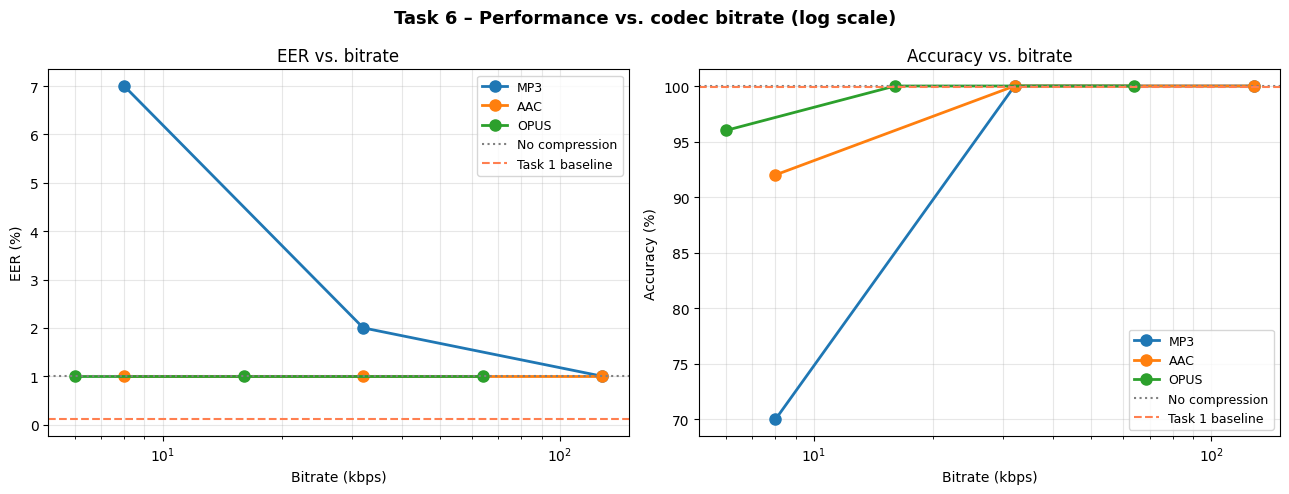

Saved: D:\pwr\biometria\lab\voice\results\task6_bitrate_curves.png


In [14]:
CODECS = ["mp3", "aac", "opus"]
CODEC_COLORS = {"mp3": "#1f77b4", "aac": "#ff7f0e", "opus": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

no_compress_row = next((r for r in rows if r["codec"] is None), None)

for ax, metric_key, ylabel, title in [
    (axes[0], "eer_pct",      "EER (%)",      "EER vs. bitrate"),
    (axes[1], "accuracy_pct", "Accuracy (%)", "Accuracy vs. bitrate"),
]:
    for codec in CODECS:
        codec_rows = [r for r in rows if r["codec"] == codec]
        if not codec_rows:
            continue
        bitrates = [r["bitrate_kbps"] for r in codec_rows]
        vals     = [r[metric_key]     for r in codec_rows]
        ax.plot(
            bitrates, vals, "o-",
            color=CODEC_COLORS[codec], linewidth=2, markersize=8,
            label=codec.upper(),
        )

    if no_compress_row:
        ax.axhline(
            no_compress_row[metric_key], color="gray",
            linestyle=":", linewidth=1.5, label="No compression",
        )
    ax.axhline(
        task1["eer_pct" if metric_key == "eer_pct" else "accuracy_at_eer_pct"],
        color="coral", linestyle="--", linewidth=1.5, label="Task 1 baseline",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Bitrate (kbps)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which="both")

fig.suptitle("Task 6 – Performance vs. codec bitrate (log scale)", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task6_bitrate_curves.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 8. Score distributions (per codec × bitrate)

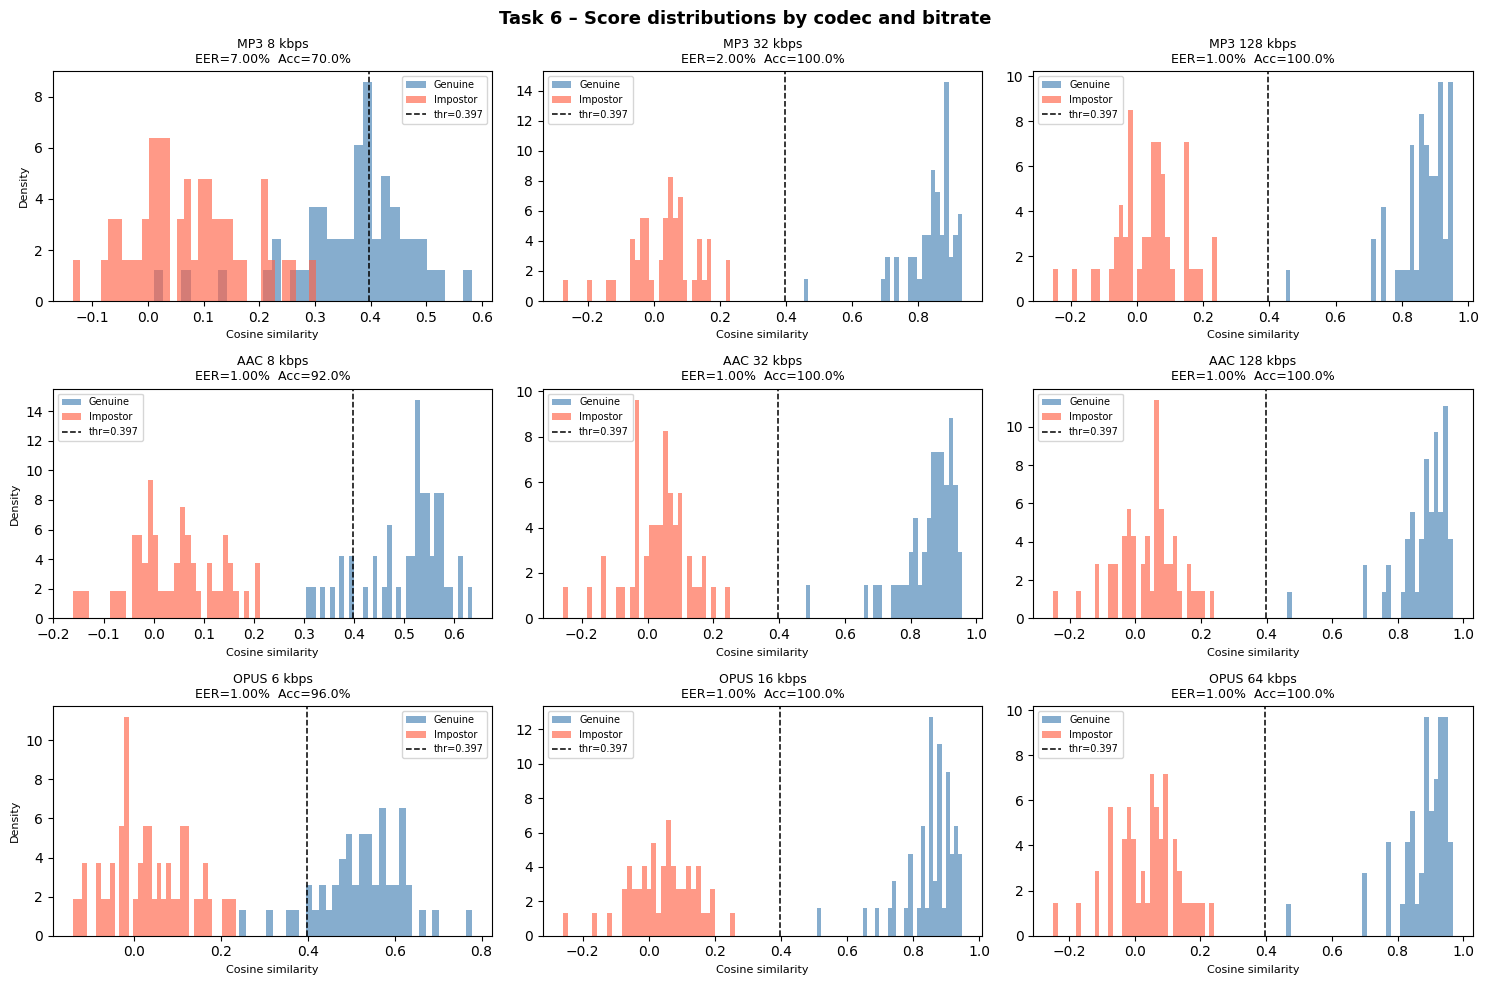

Saved: D:\pwr\biometria\lab\voice\results\task6_score_distributions.png


In [15]:
# 3 rows (codecs) × 3 columns (bitrates)
codec_bitrates = {
    "mp3":  [8,  32,  128],
    "aac":  [8,  32,  128],
    "opus": [6,  16,  64],
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey=False)

for row_idx, codec in enumerate(CODECS):
    bitrates = codec_bitrates[codec]
    codec_rows = [r for r in rows if r["codec"] == codec]

    for col_idx, bitrate in enumerate(bitrates):
        ax = axes[row_idx][col_idx]
        r = next((r for r in codec_rows if r["bitrate_kbps"] == bitrate), None)
        if r is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            continue

        key = r["key"]
        gen = np.array(results[key]["genuine"])
        imp = np.array(results[key]["impostor"])

        ax.hist(gen, bins=35, alpha=0.65, color="steelblue", density=True, label="Genuine")
        ax.hist(imp, bins=35, alpha=0.65, color="tomato",    density=True, label="Impostor")
        ax.axvline(eer_threshold, color="black", linestyle="--", linewidth=1.1,
                   label=f"thr={eer_threshold:.3f}")

        eer_f, _ = compute_eer(gen, imp)
        ax.set_title(
            f"{codec.upper()} {bitrate} kbps\nEER={eer_f*100:.2f}%  Acc={r['accuracy_pct']:.1f}%",
            fontsize=9,
        )
        ax.set_xlabel("Cosine similarity", fontsize=8)
        if col_idx == 0:
            ax.set_ylabel("Density", fontsize=8)
        ax.legend(fontsize=7)

fig.suptitle("Task 6 – Score distributions by codec and bitrate", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task6_score_distributions.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 9. Comparison bar chart vs. Task 1

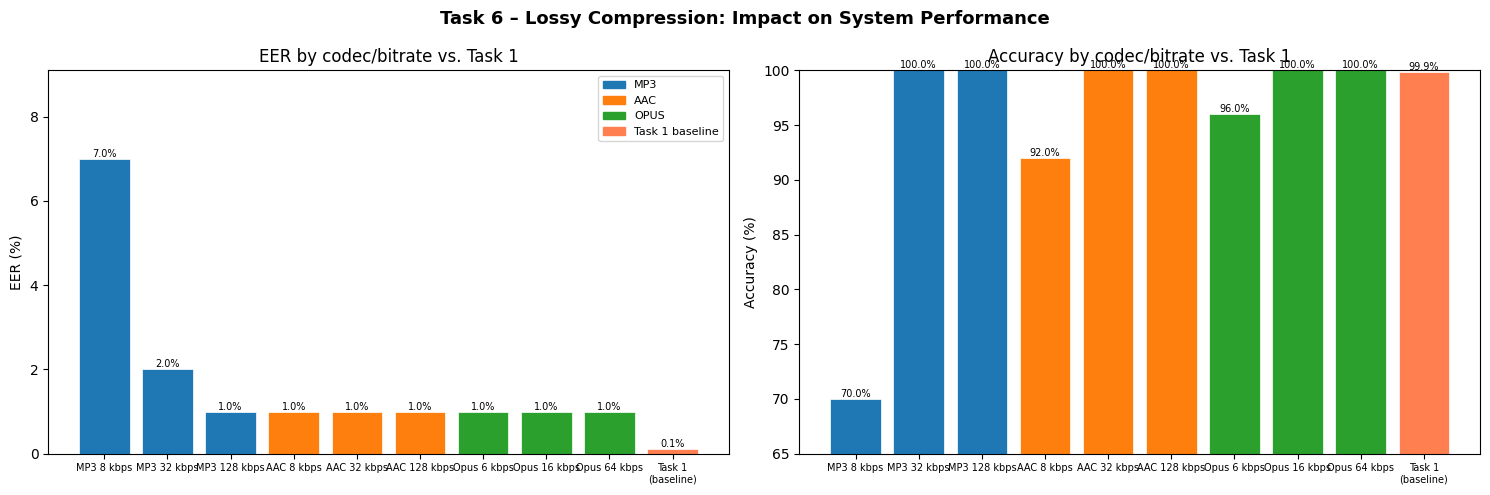

Saved: D:\pwr\biometria\lab\voice\results\task6_comparison.png


In [16]:
# Show only compressed conditions (exclude control) + Task 1
cmp_rows = [r for r in rows if r["codec"] is not None]
labels   = [r["label"]        for r in cmp_rows] + ["Task 1\n(baseline)"]
eer_cmp  = [r["eer_pct"]      for r in cmp_rows] + [task1["eer_pct"]]
acc_cmp  = [r["accuracy_pct"] for r in cmp_rows] + [task1["accuracy_at_eer_pct"]]

# Color by codec family
bar_colors = []
for r in cmp_rows:
    base = CODEC_COLORS.get(r["codec"], "gray")
    bar_colors.append(base)
bar_colors.append("coral")  # Task 1

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, vals, ylabel, title in [
    (axes[0], eer_cmp,  "EER (%)",      "EER by codec/bitrate vs. Task 1"),
    (axes[1], acc_cmp,  "Accuracy (%)", "Accuracy by codec/bitrate vs. Task 1"),
]:
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=7)

axes[0].set_ylim(0, max(eer_cmp) * 1.3)
axes[1].set_ylim(max(0, min(acc_cmp) - 5), 100)

# Legend for codec families
from matplotlib.patches import Patch
legend_handles = [Patch(color=CODEC_COLORS[c], label=c.upper()) for c in CODECS]
legend_handles.append(Patch(color="coral", label="Task 1 baseline"))
axes[0].legend(handles=legend_handles, fontsize=8)

fig.suptitle("Task 6 – Lossy Compression: Impact on System Performance", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task6_comparison.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 10. Save results

In [17]:
summary = {
    "task": 6,
    "description": "Lossy compression: MP3 (8/32/128 kbps), AAC (8/32/128 kbps), Opus (6/16/64 kbps)",
    "n_trials": len(trials),
    "eer_threshold_used": eer_threshold,
    "per_condition": rows,
    "task1_eer_pct":      task1["eer_pct"],
    "task1_accuracy_pct": task1["accuracy_at_eer_pct"],
}

out_json = RESULTS_DIR / "task6_results.json"
with open(out_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "═" * 60)
print("  TASK 6 – LOSSY COMPRESSION RESULTS")
print("═" * 60)
print(f"  {'Condition':<17} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")

prev_codec = object()
for r in rows:
    if r["codec"] != prev_codec:
        prev_codec = r["codec"]
        print(f"  --- {(r['codec'] or 'control').upper()} ---")
    print(
        f"  {r['label']:<17} {r['eer_pct']:>8.2f}"
        f" {r['far_pct']:>8.2f} {r['frr_pct']:>8.2f} {r['accuracy_pct']:>8.2f}"
    )

print("  --- BASELINE ---")
print(
    f"  {'Task 1':<17} {task1['eer_pct']:>8.2f}"
    f" {task1['far_at_eer_pct']:>8.2f} {task1['frr_at_eer_pct']:>8.2f} {task1['accuracy_at_eer_pct']:>8.2f}"
)
print("═" * 60)
print(f"\nJSON saved: {out_json}")


════════════════════════════════════════════════════════════
  TASK 6 – LOSSY COMPRESSION RESULTS
════════════════════════════════════════════════════════════
  Condition             EER%     FAR%     FRR%     Acc%
  --- CONTROL ---
  No compress           1.00     0.00     0.00   100.00
  --- MP3 ---
  MP3 8 kbps            7.00     0.00    60.00    70.00
  MP3 32 kbps           2.00     0.00     0.00   100.00
  MP3 128 kbps          1.00     0.00     0.00   100.00
  --- AAC ---
  AAC 8 kbps            1.00     0.00    16.00    92.00
  AAC 32 kbps           1.00     0.00     0.00   100.00
  AAC 128 kbps          1.00     0.00     0.00   100.00
  --- OPUS ---
  Opus 6 kbps           1.00     0.00     8.00    96.00
  Opus 16 kbps          1.00     0.00     0.00   100.00
  Opus 64 kbps          1.00     0.00     0.00   100.00
  --- BASELINE ---
  Task 1                0.11     0.14     0.07    99.89
════════════════════════════════════════════════════════════

JSON saved: D:\pwr\biometr